In [1]:
!pip install pandas matplotlib scikit-learn wandb nbformat

In [2]:
# Cell 1
import pandas as pd
import numpy as np
import gzip
import json
import urllib.request
import matplotlib.pyplot as plt
import os
import re

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

# Evaluation libraries
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)

print("Libraries loaded successfully!")
print("Scikit-learn is ready for Naive Bayes.")

Libraries loaded successfully!
Scikit-learn is ready for Naive Bayes.


In [3]:
# Cell 2
import os

url = "https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/review_categories/All_Beauty.jsonl.gz"
file_name = "All_Beauty.jsonl.gz"

if os.path.exists(file_name):
    print(f"'{file_name}' already exists, skipping download.")
else:
    print("Downloading dataset (this may take a moment)...")
    urllib.request.urlretrieve(url, file_name)
    print("Download complete.")

print("Streaming JSONL.GZ file into a balanced dataset...")

TARGET_PER_CLASS = 50_000   #50k positive + 50k negative = 100k total
chunk_size       = 10_000

pos_list, neg_list = [], []

with gzip.open(file_name, "rt", encoding="utf-8") as f:
    chunk = []
    for i, line in enumerate(f):
        chunk.append(json.loads(line))
        if len(chunk) == chunk_size:
            cdf     = pd.DataFrame(chunk).dropna(subset=["text", "rating"])
            pos_list.append(cdf[cdf["rating"] >= 4])
            neg_list.append(cdf[cdf["rating"] <= 2])
            chunk = []

            cur_pos = sum(len(c) for c in pos_list)
            cur_neg = sum(len(c) for c in neg_list)
            print(f"  Collected: {cur_pos:,} Pos | {cur_neg:,} Neg ...", end="\r")
            if cur_pos >= TARGET_PER_CLASS and cur_neg >= TARGET_PER_CLASS:
                print("\n  Target reached! Stopping stream.")
                break

df_pos = pd.concat(pos_list).iloc[:TARGET_PER_CLASS]
df_neg = pd.concat(neg_list).iloc[:TARGET_PER_CLASS]

df = pd.concat([df_pos, df_neg]).sample(frac=1, random_state=42).reset_index(drop=True)

# 3-star reviews that were naturally excluded
with gzip.open(file_name, "rt", encoding="utf-8") as f:
    neutral_count = sum(1 for line in f if json.loads(line).get("rating") == 3.0)

print(f"\nDataset loaded!")
print(f"  3-star (neutral) reviews excluded : {neutral_count:,}")
print(f"  Positive reviews (4-5 stars)      : {len(df_pos):,}")
print(f"  Negative reviews (1-2 stars)      : {len(df_neg):,}")
print(f"  Total balanced dataset            : {len(df):,}")
df.head(3)

'All_Beauty.jsonl.gz' already exists, skipping download.
Streaming JSONL.GZ file into a balanced dataset...
  Collected: 205,153 Pos | 50,289 Neg ...
  Target reached! Stopping stream.

Dataset loaded!
  3-star (neutral) reviews excluded : 56,307
  Positive reviews (4-5 stars)      : 50,000
  Negative reviews (1-2 stars)      : 50,000
  Total balanced dataset            : 100,000


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,1.0,What a rip off,It wasnt a lot of money but its enuf to be mad...,[{'small_image_url': 'https://m.media-amazon.c...,B08VVYQW5M,B08VVYQW5M,AHNYEGDY3RUR56JN67YPEKH36K2Q,1632453440474,0,True
1,1.0,Pass,Didn’t like the 2 shapes,[],B07D8FJ9HS,B07D8FJ9HS,AEYWQIUDMJGLI2WLE5LDV3DX3W6Q,1556218977010,0,True
2,4.0,Help provide relief for my feet.,I suffer from having hard skin around the heel...,[],B017BEEJ54,B017BEEJ54,AHU5HFBGOXKQTGYH7CAYOC7HQCBA,1468000594000,0,False


In [4]:
# Cell 3 (Updated with Balancing Pipeline and 3-Star Count)
from sklearn.utils import resample
import pandas as pd

def preprocess_and_balance_data(df, random_seed=42):
    # Combine title and text to give models maximum context
    df = df.copy()
    df['full_text'] = df['title'].fillna('') + " " + df['text'].fillna('')

    # Drop rows that are completely empty
    df = df[df['full_text'].str.strip() != ""]

    # Create binary sentiment labels (4 & 5 stars -> 1, 1 & 2 stars -> 0)
    df['sentiment'] = df['rating'].apply(lambda x: 1 if x > 3 else 0)

    # Separate the reviews into majority and minority classes
    positive_reviews = df[df['sentiment'] == 1]
    negative_reviews = df[df['sentiment'] == 0]

    min_class_size = min(len(positive_reviews), len(negative_reviews))

    # Downsample the classes to match the minimum class size
    pos_downsampled = resample(positive_reviews,
                               replace=False,
                               n_samples=min_class_size,
                               random_state=random_seed)

    neg_downsampled = resample(negative_reviews,
                               replace=False,
                               n_samples=min_class_size,
                               random_state=random_seed)

    # Combine the downsampled classes back together
    balanced_df = pd.concat([pos_downsampled, neg_downsampled])

    # Shuffle the dataset
    balanced_df = balanced_df.sample(frac=1, random_state=random_seed).reset_index(drop=True)

    return balanced_df, pos_downsampled, neg_downsampled

print("Balancing the dataset...")
balanced_df, pos_df, neg_df = preprocess_and_balance_data(df)

# `neutral_count` was already computed in Cell 2 (3-star reviews are never
# collected into `df`, so it can't be recounted here)
print(f"Dataset balanced successfully!")
print(f"Total 3-star (neutral) reviews dropped: {neutral_count:,}")
print(f"Total reviews kept for training: {len(balanced_df)}")
print(f"Positive reviews: {len(pos_df)} | Negative reviews: {len(neg_df)}")

# Text preprocessing for Naive Bayes + TF-IDF
lemmatizer = WordNetLemmatizer()
negation_words = {"no", "not", "nor", "never", "cannot"}
stop_words = set(stopwords.words("english")) - negation_words

def preprocess_for_naive_bayes(text: str) -> str:
    text = text.lower()
    text = re.sub(r"n['’]t\b", " not", text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) >= 3]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return " ".join(tokens)

print("Applying preprocessing pipeline to Naive Bayes reviews...")
print("(Lowercase -> Remove noise -> Tokenize -> Stopwords except negations -> Lemmatize)\n")
balanced_df["text_clean"] = balanced_df["full_text"].apply(preprocess_for_naive_bayes)

# Extract the features (X) and labels (y) for Cell 4 to use
texts = balanced_df['text_clean'].values
labels = balanced_df['sentiment'].values

Balancing the dataset...
Dataset balanced successfully!
Total 3-star (neutral) reviews dropped: 56,307
Total reviews kept for training: 100000
Positive reviews: 50000 | Negative reviews: 50000


In [5]:
# Cell 4
# Split into 75% training data and 25% testing data
X_train, X_test, y_train, y_test = train_test_split(
    texts,
    labels,
    test_size=0.25,
    random_state=42,
    stratify=labels
)

# Convert text into TF-IDF features
vectorizer = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    min_df=3,
    sublinear_tf=True
)

print("Fitting TF-IDF vectorizer...")
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Training data shape: {X_train_tfidf.shape}")
print(f"Testing data shape: {X_test_tfidf.shape}")

Fitting TF-IDF vectorizer...
Training data shape: (75000, 15000)
Testing data shape: (25000, 15000)


In [6]:
# Cell 5
model = MultinomialNB(alpha=1.0)

print("Naive Bayes model created successfully!")
print(model)

Naive Bayes model created successfully!
MultinomialNB()


In [7]:
# Cell 6
print("Starting model training...")

model.fit(X_train_tfidf, y_train)

print("Training complete!")

Starting model training...
Training complete!


In [8]:
# Cell 7
y_pred = model.predict(X_test_tfidf)
y_proba = model.predict_proba(X_test_tfidf)[:, 1]

print("--- Naive Bayes Model Performance ---")
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))

--- Naive Bayes Model Performance ---
              precision    recall  f1-score   support

    Negative       0.93      0.95      0.94     12500
    Positive       0.95      0.93      0.94     12500

    accuracy                           0.94     25000
   macro avg       0.94      0.94      0.94     25000
weighted avg       0.94      0.94      0.94     25000



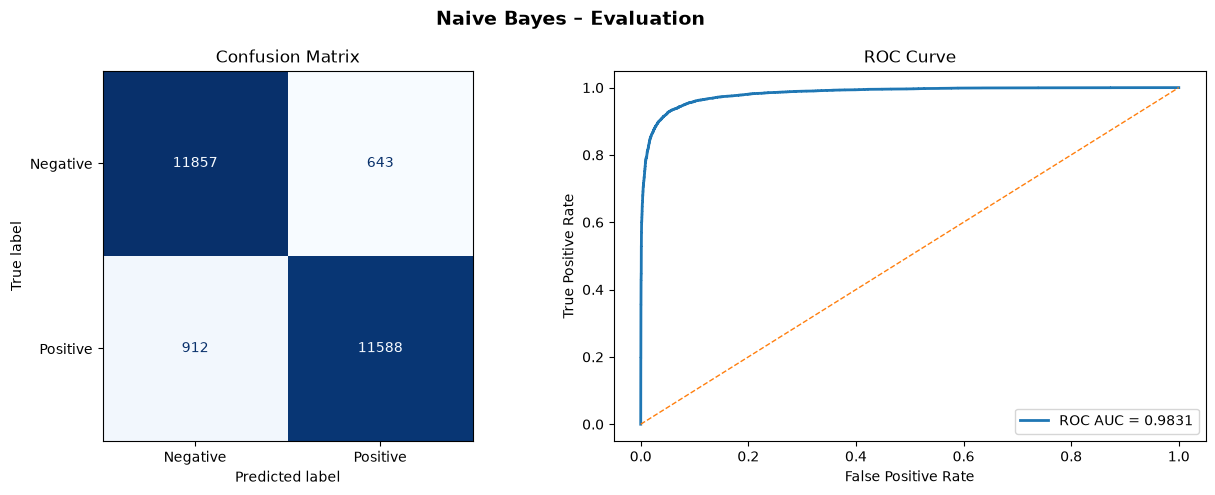

In [9]:
# Cell 8
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Naive Bayes – Evaluation", fontsize=14, fontweight="bold")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Negative", "Positive"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, lw=2, label=f"ROC AUC = {roc_auc:.4f}")
axes[1].plot([0, 1], [0, 1], linestyle="--", lw=1)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

In [10]:
# Cell 9
def predict_sentiment(review_text):
    # Apply the same preprocessing used during training, then convert to TF-IDF
    review_clean = preprocess_for_naive_bayes(review_text)
    review_tfidf = vectorizer.transform([review_clean])

    # Predict sentiment
    pred = model.predict(review_tfidf)[0]
    proba = model.predict_proba(review_tfidf)[0][1]

    sentiment = "Positive" if pred == 1 else "Negative"

    print(f"Review: '{review_text}'")
    print(f"Sentiment: {sentiment}")
    print(f"Positive Probability: {proba:.4f}\n")


predict_sentiment("These shoes look amazing and fit perfectly. Best purchase ever!")
predict_sentiment("Terrible quality. The fabric ripped after one wash. Do not buy.")
predict_sentiment("It's okay, but honestly a little overpriced for what you get.")

Review: 'These shoes look amazing and fit perfectly. Best purchase ever!'
Sentiment: Positive
Positive Probability: 0.9803

Review: 'Terrible quality. The fabric ripped after one wash. Do not buy.'
Sentiment: Negative
Positive Probability: 0.0054

Review: 'It's okay, but honestly a little overpriced for what you get.'
Sentiment: Negative
Positive Probability: 0.1757



In [11]:
# Cell 10 - Weights & Biases Logging

import wandb

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

# Close previous run if one exists
wandb.finish()

# Start a new W&B run
run = wandb.init(
    entity="aiml2026",
    project="amazon-sentiment-analysis",
    group="naive-bayes",
    job_type="train",
    name="naive-bayes",
    tags=["naive-bayes", "tfidf"],
    config={
        "model": "Multinomial Naive Bayes",
        "alpha": 1.0,
        "tfidf_max_features": 15000,
        "ngram_range": "(1,2)",
        "train_size": len(X_train),
        "test_size": len(X_test),
    }
)

# Predictions
y_pred = model.predict(X_test_tfidf)
y_proba = model.predict_proba(X_test_tfidf)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc_value = roc_auc_score(y_test, y_proba)

# Log metrics
wandb.log({
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "ROC_AUC": roc_auc_value
})

# Confusion matrix + ROC curve as native W&B charts (not static images) so they
# can be overlaid/compared against the logreg and bilstm runs in the same project.
y_true_arr = np.asarray(y_test)
y_probas = np.column_stack([1 - y_proba, y_proba])  # wandb wants a column per class

wandb.log({
    "confusion_matrix": wandb.plot.confusion_matrix(
        y_true=y_true_arr,
        preds=y_pred,
        class_names=["Negative", "Positive"],
    ),
    "roc_curve": wandb.plot.roc_curve(
        y_true=y_true_arr,
        y_probas=y_probas,
        labels=["Negative", "Positive"],
    ),
})

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC AUC  :", roc_auc_value)

wandb.finish()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/benji/.netrc.
wandb: Currently logged in as: hibenji to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Accuracy : 0.9378
Precision: 0.9474286648679585
Recall   : 0.92704
F1 Score : 0.9371234483037484
ROC AUC  : 0.9830524192000001


Accuracy,▁
F1,▁
Precision,▁
ROC_AUC,▁
Recall,▁
Accuracy,0.9378
F1,0.93712
Precision,0.94743
ROC_AUC,0.98305
Recall,0.92704
